# 💻 PROYECTO FINAL DE CONSULTORÍA  
### 📊 Clasificación de Emociones en Redes Sociales


**Estudiante:** *Dayana Alejandra Rincón Pardo*  
**Fecha de entrega:** *3 de junio de 2024*


# **Explorando los datos: ¿Qué información tenemos y cómo se ve?**

## **¿Qué emociones predominan según el uso que las personas hacen de redes sociales?**

En este proyecto, tenemos una base que resume el comportamiento de diferentes personas en redes sociales (por ejemplo, cuánto tiempo pasan en ellas, qué tanto interactúan, cuántos “me gusta” reciben, etc.) y la emoción que predomina en cada una de ellas (como alegría, tristeza, ansiedad...).

### **1. Primero cargamos los datos y hacemos una revisión rápida para verificar que esté todo en orden:**

In [2]:
import pandas as pd

# Cargar los datos
df = pd.read_csv('/content/train.csv')

# Mostrar primeras filas
df.head()

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


### Antes de empezar a analizar, es importante revisar si la base tiene problemas: columnas vacías, tipos de datos incorrectos o valores perdidos. Esta parte nos ayuda a tener claro con qué estamos trabajando y si hay que hacer algún ajuste.

In [3]:
# Revisar estructura general
df.info()

# Verificar si hay valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB
Valores nulos por columna:
User_ID                       0
Age                           0
Gender                        1
Platform                      1
D

Al revisar las primeras filas, vimos que esta base muestra cómo se comportan distintas personas en redes sociales: cuánto tiempo las usan al día, cuántos posts hacen, cuántos “me gusta” o mensajes reciben, y qué emoción es la más frecuente en cada caso (como alegría, tristeza o ansiedad).

**Después, revisamos la estructura completa y el contenido de la base:**

Tiene 10 columnas y 1001 registros.

Algunas variables son numéricas (como tiempo de uso o número de posts), y otras son texto (como la plataforma o la emoción).

**También detectamos algo importante:**

Hay valores faltantes en varias columnas, justo 1 valor nulo por columna excepto en la columna User_ID (que está completa).

Esto quiere decir que hay algunos registros con información incompleta que debemos tratar antes de avanzar.

## **2. Segundo realizamos limpieza e imputación de datos**

Después de cargar los datos, el siguiente paso fue revisar si había valores faltantes y preparar las columnas para que sean más fáciles de usar.

🧾 **¿Qué hicimos aquí?**
Revisamos los nombres de las columnas:
A veces los nombres de las columnas vienen con espacios o mayúsculas. Para evitar errores más adelante, les quitamos los espacios y los pasamos a minúsculas. También eliminamos los paréntesis que tenían algunas columnas.

**Convertimos la columna 'age' a número:**
Aunque parecía ser un número, venía como texto. Usamos pd.to_numeric() para convertirla a entero. Si había algún error o texto extraño, se cambió automáticamente a NaN.

**Eliminamos los valores nulos de 'age':**
Como la edad es una variable importante para el análisis, decidimos eliminar las filas donde esa información estaba vacía.

**Volvimos a convertir la edad a tipo entero:**
Para asegurarnos de que todas las edades quedaran como números sin decimales (tipo int), hicimos una conversión final.

**Filtramos los géneros válidos:**
Solo nos quedamos con las observaciones que tenían género como "Male", "Female" o "Non-binary", descartando cualquier valor inválido o extraño.

**Imputamos las variables categóricas:**
En lugar de borrar más filas por datos faltantes en columnas como gender, platform o dominant_emotion, completamos los vacíos con el valor más común (la moda). Esto nos permite conservar más información sin introducir valores aleatorios.

**Verificación final:**
Al final revisamos que no quedaran valores nulos y confirmamos que los tipos de dato sean los correctos (int, float u object según corresponda).

**🧹 Normalización de nombres de columnas:**

In [5]:
# Revisamos los nombres originales para identificar errores de formato
print(df.columns.tolist())

['User_ID', 'Age', 'Gender', 'Platform', 'Daily_Usage_Time (minutes)', 'Posts_Per_Day', 'Likes_Received_Per_Day', 'Comments_Received_Per_Day', 'Messages_Sent_Per_Day', 'Dominant_Emotion']


In [6]:
# Normalizamos los nombres de las columnas:
# - Quitamos espacios al inicio y final
# - Ponemos todo en minúscula
# - Reemplazamos espacios por guiones bajos
# - Eliminamos paréntesis (por si los hubiera)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("(", "", regex=False)
      .str.replace(")", "", regex=False)
)

In [7]:
# Verificamos que los nombres hayan quedado limpios y uniformes
print(df.columns.tolist())

['user_id', 'age', 'gender', 'platform', 'daily_usage_time_minutes', 'posts_per_day', 'likes_received_per_day', 'comments_received_per_day', 'messages_sent_per_day', 'dominant_emotion']


In [9]:
# Convertimos la columna 'age' a tipo numérico, forzando errores como NaN
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [10]:
# Quitamos las filas donde no hay edad registrada
df = df.dropna(subset=["age"])

In [11]:
# Cambiamos el tipo de 'age' de float a entero (sin decimales)
df["age"] = df["age"].astype(int)

In [12]:
# Nos quedamos solo con valores válidos en la columna 'gender'
df = df[df["gender"].isin(["Female", "Male", "Non-binary"])].copy()

In [13]:
# Para las columnas categóricas, rellenamos los vacíos con la moda (valor más común)
cat_cols = ["gender", "platform", "dominant_emotion"]
for col in cat_cols:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

In [14]:
# Al final revisamos que ya no haya valores nulos y vemos los tipos de dato
print(df.isnull().sum())
print(df.dtypes)

user_id                      0
age                          0
gender                       0
platform                     0
daily_usage_time_minutes     0
posts_per_day                0
likes_received_per_day       0
comments_received_per_day    0
messages_sent_per_day        0
dominant_emotion             0
dtype: int64
user_id                       object
age                            int64
gender                        object
platform                      object
daily_usage_time_minutes     float64
posts_per_day                float64
likes_received_per_day       float64
comments_received_per_day    float64
messages_sent_per_day        float64
dominant_emotion              object
dtype: object


Antes de avanzar con los gráficos o modelos, confirmé que ya no hubiera valores nulos y que cada variable tenga el tipo de dato correcto. Esto evita errores más adelante y asegura que el análisis sea fiable.

## **3. Análisis Exploratorio de Datos (EDA)**

En esta sección exploramos las variables principales para entender patrones, frecuencias y relaciones generales que podrían influir en la emoción dominante.

### **📊 3.1 Distribución de emociones dominantes**

<ipython-input-23-a766dd790ae8>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


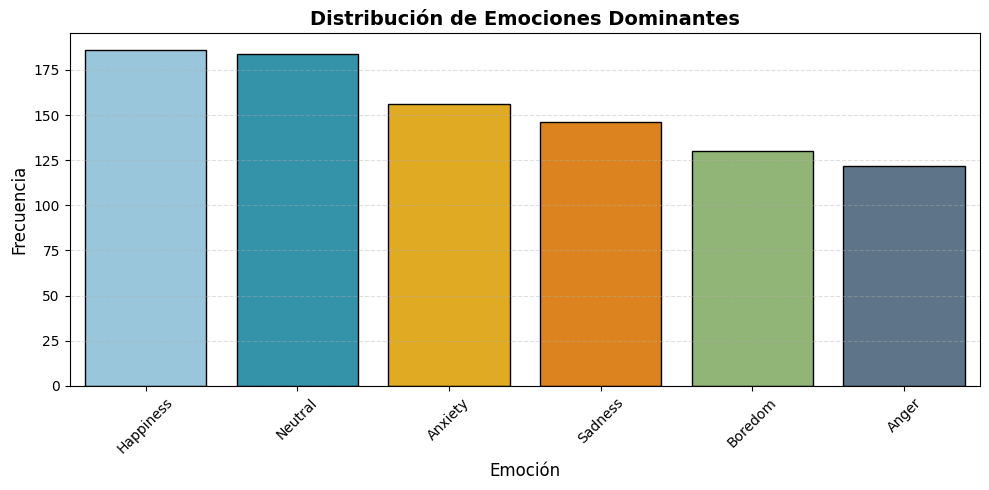

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt


# Gráfico de barras: Distribución de emociones
plt.figure(figsize=(10, 5))
palette_emotions = ["#8ecae6", "#219ebc", "#ffb703", "#fb8500", "#90be6d", "#577590"]

sns.countplot(
    x="dominant_emotion",
    data=df,
    order=df["dominant_emotion"].value_counts().index,
    palette=palette_emotions,
    edgecolor="black"
)

plt.title("Distribución de Emociones Dominantes", fontsize=14, fontweight='bold')
plt.xlabel("Emoción", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

La gráfica muestra que "Happiness" y "Neutral" son las emociones más frecuentes entre los usuarios analizados. En cambio, emociones como "Anger" y "Boredom" tienen una presencia menor

### **3.2. Distribución por género**

<ipython-input-54-885fb2ae731d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


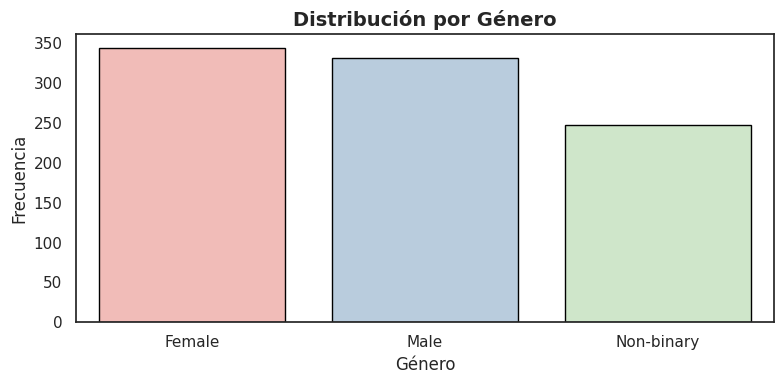

In [54]:
plt.figure(figsize=(8, 4))
sns.countplot(
    x="gender",
    data=df,
    palette="Pastel1",  # paleta suave para género
    edgecolor='black'
)

plt.title("Distribución por Género", fontsize=14, fontweight='bold')
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

<ipython-input-30-6bc19aa19aa9>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


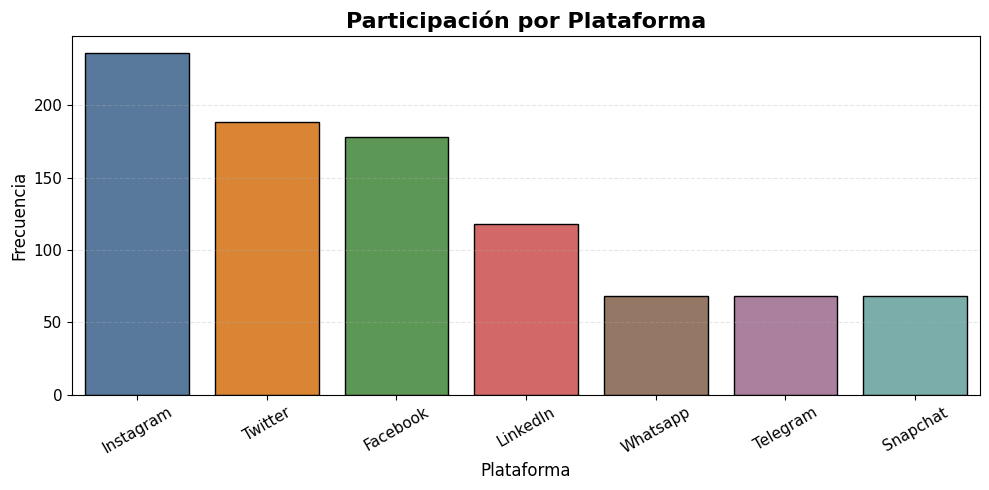

In [30]:
# Visualización de la participación según plataforma usada
plt.figure(figsize=(10, 5))

# Colores seleccionados manualmente con armonía visual
colores = [
    "#4C78A8",  # Azul sobrio
    "#F58518",  # Naranja suave
    "#54A24B",  # Verde tranquilo
    "#E45756",  # Rojo coral
    "#9D755D",  # Marrón cálido
    "#B279A2",  # Lavanda tenue
    "#72B7B2"   # Aguamarina
]

sns.countplot(
    x="platform",
    data=df,
    order=df["platform"].value_counts().index,
    palette=colores,
    edgecolor="black"
)

# Detalles del gráfico
plt.title("Participación por Plataforma", fontsize=16, fontweight="bold")
plt.xlabel("Plataforma", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## **3.4. Boxplot del tiempo de uso diario por emoción**

<ipython-input-32-721b1c116dca>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


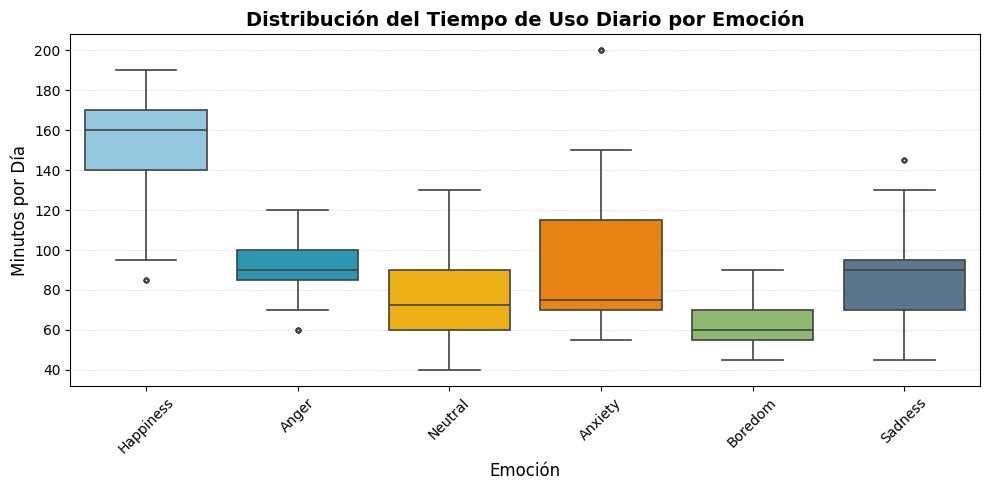

In [32]:
# Boxplot del tiempo de uso diario por emoción
plt.figure(figsize=(10, 5))

# Paleta de colores coherente con estilo anterior (tonos suaves pero distintivos)
palette_emotions = [
    "#8ecae6",  # Azul cielo
    "#219ebc",  # Azul fuerte
    "#ffb703",  # Amarillo intenso
    "#fb8500",  # Naranja
    "#90be6d",  # Verde suave
    "#577590"   # Azul petróleo oscuro
]

sns.boxplot(
    x="dominant_emotion",
    y="daily_usage_time_minutes",
    data=df,
    palette=palette_emotions,
    linewidth=1.2,
    fliersize=3,  # Tamaño de los outliers
    saturation=0.85
)

plt.title("Distribución del Tiempo de Uso Diario por Emoción", fontsize=14, weight="bold")
plt.xlabel("Emoción", fontsize=12)
plt.ylabel("Minutos por Día", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
plt.tight_layout()
plt.show()

## **3.5. Mapa de calor de correlación entre variables numéricas**

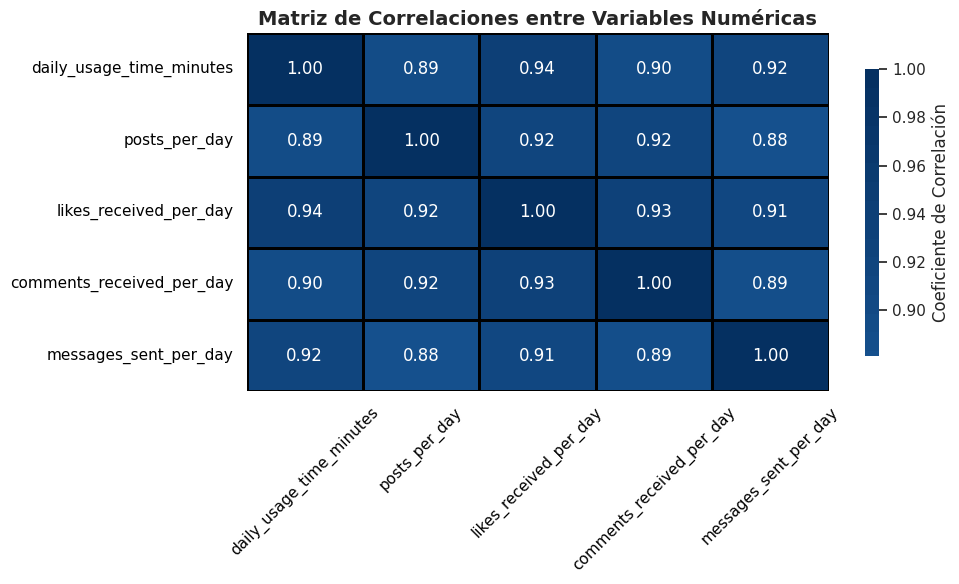

In [53]:
# Calcular la matriz de correlación
corr = df.select_dtypes(include='float64').corr()

# Configurar el gráfico
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu",          # Paleta rojo-blanco-azul (estilo profesional)
    center=0,             # Centrar en 0 para distinguir mejor correlaciones negativas y positivas
    linewidths=0.8,
    linecolor='black',
    cbar_kws={
        "shrink": 0.8,
        "label": "Coeficiente de Correlación"
    }
)

# Estética de título y ejes
ax.set_title("Matriz de Correlaciones entre Variables Numéricas", fontsize=14, weight='bold')
ax.tick_params(axis='x', colors='black', rotation=45)
ax.tick_params(axis='y', colors='black')

plt.tight_layout()
plt.show()


## **4. Ingeniería de Características**
En esta sección se construyen variables derivadas que sintetizan patrones de uso, intensidad y efectividad en la interacción social digital. Estas métricas permiten analizar comparativamente a los usuarios más allá de los datos brutos originales.

### **4.1 Total de Interacciones por Día**

Captura la actividad social total por día. Combina likes, comentarios y mensajes, permitiendo una visión agregada de la participación del usuario.

In [58]:
# 1. Total de interacciones por día
df["total_interactions_per_day"] = (
    df["likes_received_per_day"]
    + df["comments_received_per_day"]
    + df["messages_sent_per_day"]
)

Esta variable resume cuánto interactúa un usuario en total cada día.

Es útil porque concentra tres tipos distintos de engagement en una sola métrica.

### **4.2 Engagement Rate (Interacciones por Publicación)**

Evalúa la efectividad promedio por publicación. Es útil para comparar a usuarios con mucha o poca actividad: si con pocos posts generan muchas interacciones, su tasa es alta.

In [59]:
# 2. Engagement Rate (Interacciones por publicación)
df["engagement_rate"] = df["total_interactions_per_day"] / df["posts_per_day"]
df["engagement_rate"] = df["engagement_rate"].replace([float("inf"), -float("inf")], 0)

Mide la efectividad de las publicaciones: si el usuario recibe muchas interacciones con pocos posts, su tasa es alta.

El .replace evita valores infinitos cuando hay usuarios con 0 posts.

## **4.3 Interacciones por Minuto de Uso**

In [60]:
#3. Interacciones por minuto de uso
df["interactions_per_minute"] = df["total_interactions_per_day"] / df["daily_usage_time_minutes"]
df["interactions_per_minute"] = df["interactions_per_minute"].replace([float("inf"), -float("inf")], 0)

“Mide la intensidad: ¿qué tan productivo es el tiempo conectado? Un usuario puede usar poco tiempo la plataforma pero con alta eficiencia en interacciones.”

### **4.4 Interacciones por Año de Edad**

“Permite normalizar el comportamiento por edad y explorar patrones generacionales. Por ejemplo, ¿los usuarios más jóvenes interactúan proporcionalmente más?”

In [61]:
#4. Interacciones por año de edad
df["interactions_per_year_of_age"] = df["total_interactions_per_day"] / df["age"]
df["interactions_per_year_of_age"] = df["interactions_per_year_of_age"].replace([float("inf"), -float("inf")], 0)

Busca capturar posibles patrones generacionales: ¿los jóvenes generan más interacción proporcionalmente?

### **✅ Visualización de validación**

### **4.5 Validación estadística**

“Resumen estadístico de las nuevas métricas derivadas”
Explica que sirve para revisar magnitudes, outliers y rangos de comparación antes de modelar o visualizar.

In [62]:
# Validamos nuevas variables
print(df[[
    "total_interactions_per_day",
    "engagement_rate",
    "interactions_per_minute",
    "interactions_per_year_of_age"
]].describe())

       total_interactions_per_day  engagement_rate  interactions_per_minute  \
count                  924.000000       924.000000               924.000000   
mean                    78.568182        24.833172                 0.776901   
std                     43.329180         5.840077                 0.181764   
min                     17.000000         9.833333                 0.366667   
25%                     44.000000        21.500000                 0.640000   
50%                     71.000000        24.000000                 0.800000   
75%                    105.500000        28.000000                 0.916912   
max                    195.000000        51.000000                 1.200000   

       interactions_per_year_of_age  
count                    924.000000  
mean                       2.898652  
std                        1.614147  
min                        0.515152  
25%                        1.612903  
50%                        2.695652  
75%                   

### **📊 Visualizaciones derivadas**

### **4.6 Mapa de Correlación de Métricas Derivadas**

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_enhanced_correlation(df):
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid")
    corr = df[[
        "total_interactions_per_day", "engagement_rate",
        "interactions_per_minute", "interactions_per_year_of_age"
    ]].corr()

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="PuBuGn",
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )
    plt.title("Matriz de Correlación entre Métricas Derivadas", fontsize=14)
    plt.tight_layout()
    plt.show()

In [72]:
def plot_boxplot_engagement(df):
    plt.figure(figsize=(10, 5))
    sns.set(style="whitegrid")
    sns.boxplot(
        x="dominant_emotion",
        y="engagement_rate",
        data=df,
        palette="pastel",
        linewidth=1.2
    )
    plt.title("Tasa de Engagement por Emoción", fontsize=14)
    plt.xlabel("Emoción")
    plt.ylabel("Engagement Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

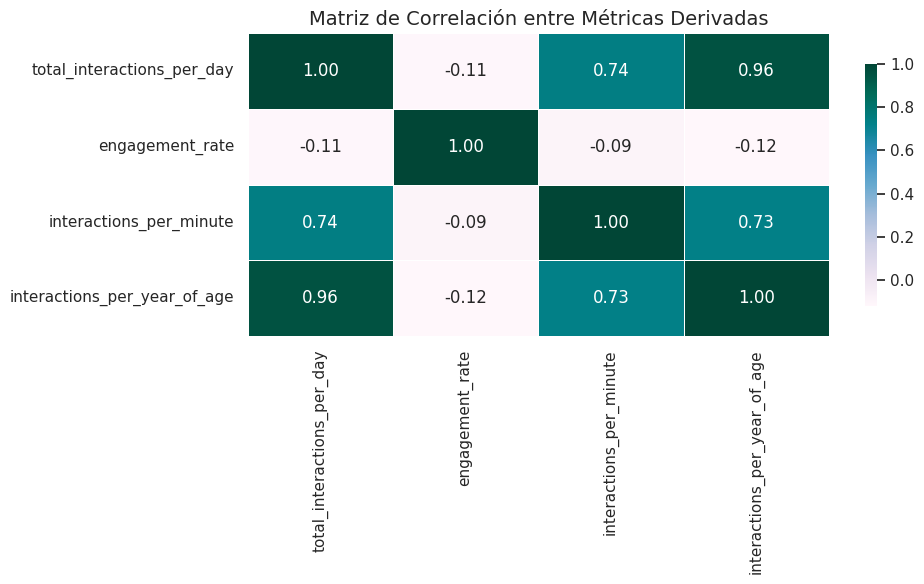

In [74]:
plot_enhanced_correlation(df)

**1.** total_interactions_per_day
Definición:
Suma de likes, comentarios y mensajes enviados por día, como aproximación al volumen de actividad diaria del usuario.

Estadísticas clave:

Media: ~78.6 interacciones/día

Máximo: 195

Distribución sesgada hacia valores más bajos

Interpretación:
La mayoría de usuarios interactúa de forma moderada, pero hay algunos outliers con actividad extremadamente alta. Esta métrica es esencial para capturar el nivel bruto de engagement diario, sin considerar tiempo ni edad.

**2.**  engagement_rate
Definición:
Interacciones totales por día dividido por número de publicaciones (likes + comments + messages / posts).
Refleja efectividad por publicación, más que volumen.

Estadísticas clave:

Media: ~24.8

Rango típico (IQR): 21.5 a 28

Outliers presentes (algunos superan 45)

Interpretación:
El engagement rate permite detectar usuarios que, con pocas publicaciones, generan alta interacción, lo cual puede ser más valioso que publicar en volumen. Ideal para identificar perfiles influyentes.

**3.** interactions_per_minute
Definición:
Proporción de interacciones por minuto de uso diario.
Evalúa eficiencia temporal en la plataforma.

Estadísticas clave:

Media: ~0.77

Mínimo: 0.37

Máximo: 1.2 (usuario que interactúa más de una vez por minuto)

Interpretación:
Esta métrica permite comparar usuarios que usan poco tiempo pero interactúan intensamente, contra quienes pasan horas con bajo nivel de acción. Es útil para evaluar el valor de tiempo conectado.

**4.** interactions_per_year_of_age
Definición:
Interacciones totales por día dividido por la edad del usuario.

Estadísticas clave:

Media: ~2.9

Máximo: 8.3

Rango intercuartílico: 1.6 a 3.8

Interpretación:
Este indicador permite ajustar la actividad por la edad, facilitando comparaciones justas entre cohortes. Usuarios más jóvenes tienden a tener mayor intensidad relativa de interacción.

### **🔍 Modelado Predictivo de Emociones**

### **Modelo: Variables Derivadas de Uso e Interacción**

### **Objetivo:** Predecir la emoción dominante a partir de métricas derivadas de comportamiento digital (uso, engagement e intensidad).

### **Variables Predictoras:**

- daily_usage_time_minutes

- posts_per_day

- likes_received_per_day

- comments_received_per_day

- messages_sent_per_day

- engagement_rate

- interactions_per_minute

- interactions_per_year_of_age

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Selecciona tus variables predictoras
X = df[['daily_usage_time_minutes', 'posts_per_day', 'likes_received_per_day',
        'comments_received_per_day', 'messages_sent_per_day',
        'engagement_rate', 'interactions_per_minute', 'interactions_per_year_of_age']]

# Variable objetivo
y = df['dominant_emotion']

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Entrenar modelo
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

Classification Report:
              precision    recall  f1-score   support

       Anger       0.96      0.96      0.96        25
     Anxiety       0.93      0.90      0.92        31
     Boredom       0.96      1.00      0.98        26
   Happiness       0.95      0.95      0.95        37
     Neutral       0.97      0.97      0.97        37
     Sadness       0.97      0.97      0.97        29

    accuracy                           0.96       185
   macro avg       0.96      0.96      0.96       185
weighted avg       0.96      0.96      0.96       185



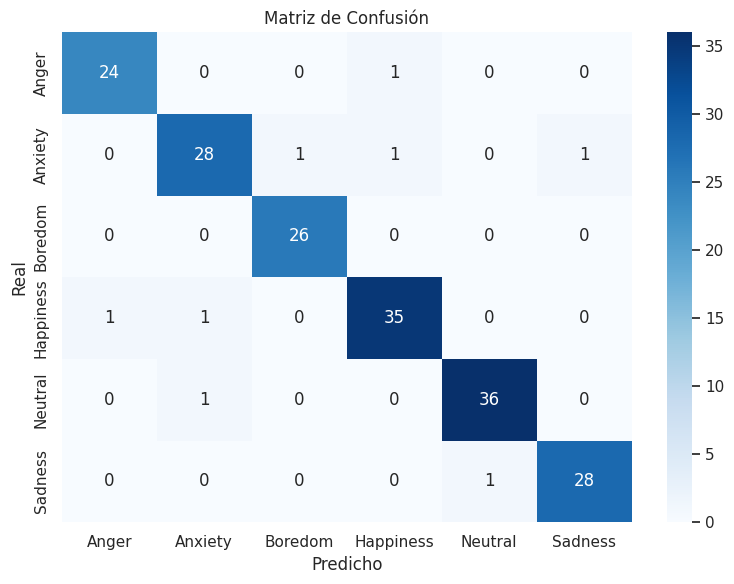

In [82]:
# Reporte de clasificación
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_prAed, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [109]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    max_depth=5,              # Árboles más pequeños
    min_samples_leaf=10,      # No dividir nodos con pocos datos
    n_estimators=100,
    random_state=42
)

In [110]:
# Entrenar nuevamente el modelo RandomForest
# model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predicciones en entrenamiento y prueba
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Cálculo de métricas
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

# Mostrar en tabla
comparison_df = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Accuracy": [round(acc_train, 4), round(acc_test, 4)]
})

from tabulate import tabulate
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))


+---------------+------------+
| Conjunto      |   Accuracy |
+===============+============+
| Entrenamiento |     0.7833 |
+---------------+------------+
| Prueba        |     0.741  |
+---------------+------------+


In [111]:
print(y_test.value_counts(normalize=True))
print(classification_report(y_test, y_test_pred))

dominant_emotion
Happiness    0.201439
Neutral      0.197842
Anxiety      0.169065
Sadness      0.158273
Boredom      0.140288
Anger        0.133094
Name: proportion, dtype: float64
              precision    recall  f1-score   support

       Anger       0.71      0.73      0.72        37
     Anxiety       0.84      0.55      0.67        47
     Boredom       0.85      0.72      0.78        39
   Happiness       0.82      0.89      0.85        56
     Neutral       0.58      0.85      0.69        55
     Sadness       0.82      0.64      0.72        44

    accuracy                           0.74       278
   macro avg       0.77      0.73      0.74       278
weighted avg       0.77      0.74      0.74       278



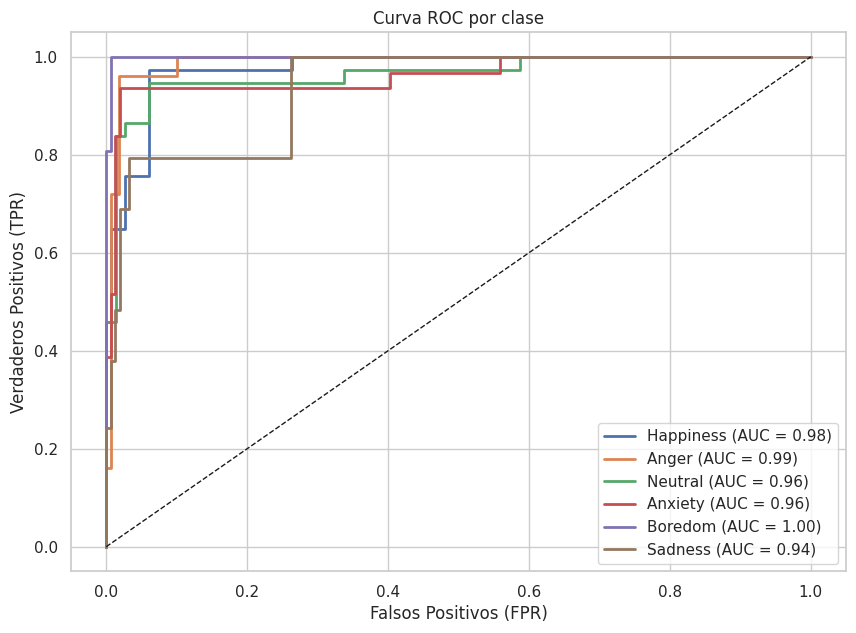

AUC Macro: 0.971 | AUC Weighted: 0.970


In [112]:
# Librerías
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Variables predictoras
X = df[['daily_usage_time_minutes', 'posts_per_day', 'likes_received_per_day',
        'comments_received_per_day', 'messages_sent_per_day',
        'engagement_rate', 'interactions_per_minute', 'interactions_per_year_of_age']]

# Variable objetivo
y = df['dominant_emotion']
classes = y.unique()

# Binarización de clases (requerido para ROC multiclase)
y_bin = label_binarize(y, classes=classes)
n_classes = y_bin.shape[1]

# Split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, test_size=0.2, stratify=y, random_state=42)

# Modelo RandomForest con One-vs-Rest
model = OneVsRestClassifier(RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
))
model.fit(X_train, y_train_bin)

# Predicción probabilística
y_score = model.predict_proba(X_test)

# ROC por clase
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Falsos Positivos (FPR)')
plt.ylabel('Verdaderos Positivos (TPR)')
plt.title('Curva ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# AUC agregados
auc_macro = roc_auc_score(y_test_bin, y_score, average='macro')
auc_weighted = roc_auc_score(y_test_bin, y_score, average='weighted')
print(f"AUC Macro: {auc_macro:.3f} | AUC Weighted: {auc_weighted:.3f}")

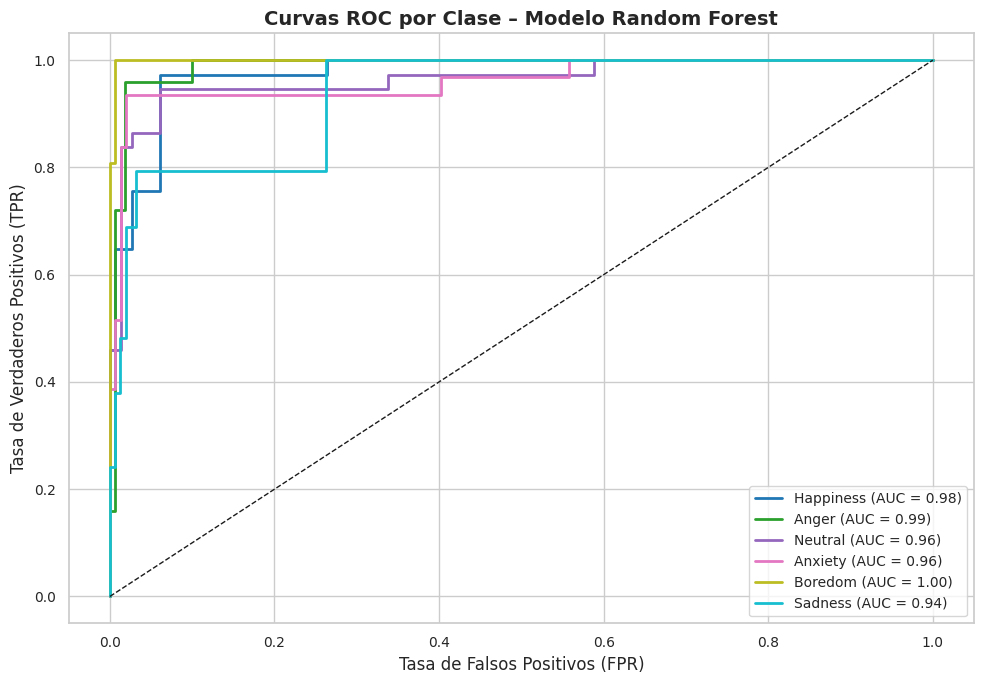

AUC Macro Promedio: 0.971
AUC Ponderado por Clase: 0.970


In [113]:
# ======================
# 📦 LIBRERÍAS
# ======================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ======================
# 📊 PREPARACIÓN DE DATOS
# ======================
# Variables predictoras
X = df[['daily_usage_time_minutes', 'posts_per_day', 'likes_received_per_day',
        'comments_received_per_day', 'messages_sent_per_day',
        'engagement_rate', 'interactions_per_minute', 'interactions_per_year_of_age']]

# Variable objetivo
y = df['dominant_emotion']
classes = y.unique()
y_bin = label_binarize(y, classes=classes)
n_classes = y_bin.shape[1]

# División train/test
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, test_size=0.2, stratify=y, random_state=42)

# ======================
# 🧠 MODELO Random Forest + One-vs-Rest
# ======================
model = OneVsRestClassifier(RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
))
model.fit(X_train, y_train_bin)

# ======================
# 📈 CURVAS ROC
# ======================
y_score = model.predict_proba(X_test)
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

plt.figure(figsize=(10, 7))

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})', color=color)

# Línea de referencia
plt.plot([0, 1], [0, 1], 'k--', lw=1)

# Estilo del gráfico
plt.title('Curvas ROC por Clase – Modelo Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.legend(loc='lower right', fontsize=10)

# Guardar figura en alta resolución (opcional)
plt.tight_layout()
plt.savefig('curva_ROC_multiclase.png', dpi=300)
plt.show()

# ======================
# 📊 MÉTRICAS GLOBALES
# ======================
auc_macro = roc_auc_score(y_test_bin, y_score, average='macro')
auc_weighted = roc_auc_score(y_test_bin, y_score, average='weighted')
print(f"AUC Macro Promedio: {auc_macro:.3f}")
print(f"AUC Ponderado por Clase: {auc_weighted:.3f}")


## **Modelo Multinomial**

In [92]:
# Repetimos la codificación de etiquetas y el entrenamiento para asegurar que 'le' esté definido
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Entrenamiento con más iteraciones para evitar warning de convergencia
model_mnlogit = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=5000)
model_mnlogit.fit(X_train, y_train)

# Extraer los coeficientes con etiquetas
coef_df = pd.DataFrame(
    model_mnlogit.coef_,
    columns=X.columns,
    index=le.inverse_transform(np.unique(y_encoded))
)

# Agregar columna del intercepto
coef_df.insert(0, 'Intercepto', model_mnlogit.intercept_)

# Transformar en formato largo para presentación
coef_long = coef_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Coeficiente')
coef_long.rename(columns={'index': 'Emoción'}, inplace=True)

# Calcular odds ratio (e^coeficiente)
coef_long['Odds Ratio'] = np.exp(coef_long['Coeficiente'])


# Mostrar en consola una versión elegante y bien formateada
import tabulate

# Seleccionamos algunas columnas relevantes para mejor visualización
pretty_table = coef_long[['Emoción', 'Variable', 'Coeficiente', 'Odds Ratio']]

# Redondear para visualización más clara
pretty_table['Coeficiente'] = pretty_table['Coeficiente'].round(3)
pretty_table['Odds Ratio'] = pretty_table['Odds Ratio'].round(3)

# Mostrar como tabla con formato grid
print(tabulate.tabulate(pretty_table, headers='keys', tablefmt='grid', showindex=False))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


+-----------+------------------------------+---------------+--------------+
| Emoción   | Variable                     |   Coeficiente |   Odds Ratio |
+===========+==============================+===============+==============+
| Anger     | Intercepto                   |         5.559 |      259.529 |
+-----------+------------------------------+---------------+--------------+
| Anxiety   | Intercepto                   |        -2.728 |        0.065 |
+-----------+------------------------------+---------------+--------------+
| Boredom   | Intercepto                   |         1.68  |        5.366 |
+-----------+------------------------------+---------------+--------------+
| Happiness | Intercepto                   |        -9.42  |        0     |
+-----------+------------------------------+---------------+--------------+
| Neutral   | Intercepto                   |         0.984 |        2.674 |
+-----------+------------------------------+---------------+--------------+
| Sadness   

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [94]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Reescalamos los datos antes de usar statsmodels
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Agregamos constante para el modelo
X_scaled_const = sm.add_constant(X_scaled)

# Convertimos la variable dependiente a categórica para statsmodels
y_categorical = pd.Categorical(y)

# Creamos el modelo multinomial con statsmodels para calcular AIC
model_sm = sm.MNLogit(y_categorical.codes, X_scaled_const)
result = model_sm.fit(maxiter=500, disp=False)

# Obtenemos el AIC
aic_value = result.aic
aic_value

np.float64(2132.2656138902676)

In [97]:
from statsmodels.tools import add_constant
from itertools import combinations

# Lista de variables originales
variables = list(X.columns)

# Preparar estructura para registrar resultados
aic_results = []

# Realizamos selección backward: comenzamos con todas las variables y vamos eliminando de a una
for k in range(len(variables), 0, -1):
    for subset in combinations(variables, k):
        X_subset = X[list(subset)]
        X_subset_scaled = scaler.fit_transform(X_subset)
        X_subset_scaled_const = add_constant(X_subset_scaled)

        try:
            model = sm.MNLogit(y_categorical.codes, X_subset_scaled_const)
            result = model.fit(maxiter=500, disp=False)
            aic_results.append({
                'Variables': subset,
                'AIC': result.aic
            })
        except Exception:
            continue

# Convertimos los resultados en un DataFrame ordenado por menor AIC
aic_df = pd.DataFrame(aic_results).sort_values(by='AIC').reset_index(drop=True)

# Mostramos en consola las mejores combinaciones de variables con su AIC
from tabulate import tabulate

# Seleccionamos las 10 mejores combinaciones
top_aic_df = aic_df.head(10).copy()
top_aic_df['Variables'] = top_aic_df['Variables'].apply(lambda x: ', '.join(x))
top_aic_df['AIC'] = top_aic_df['AIC'].round(3)

# Mostrar como tabla en consola
print(tabulate(top_aic_df, headers='keys', tablefmt='grid', showindex=True))



+----+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|    | Variables                                                                                                                                                                                 |     AIC |
+====+===========================================================================================================================================================================================+=========+
|  0 | daily_usage_time_minutes, posts_per_day, likes_received_per_day, comments_received_per_day, messages_sent_per_day, engagement_rate, interactions_per_minute, interactions_per_year_of_age | 2132.27 |
+----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [98]:
# Definimos el subconjunto de variables del mejor modelo según el AIC más bajo
best_vars = [
    'daily_usage_time_minutes',
    'posts_per_day',
    'likes_received_per_day',
    'comments_received_per_day',
    'messages_sent_per_day',
    'engagement_rate',
    'interactions_per_minute',
    'interactions_per_year_of_age'
]

# Filtramos el dataset con las mejores variables
X_best = X[best_vars]
X_best_scaled = scaler.fit_transform(X_best)
X_best_scaled_const = sm.add_constant(X_best_scaled)

# Ajustamos el modelo multinomial con statsmodels
model_best = sm.MNLogit(y_categorical.codes, X_best_scaled_const)
result_best = model_best.fit(maxiter=500, disp=False)

# Extraer coeficientes y convertir a DataFrame
coef_table = pd.DataFrame(result_best.params)
coef_table.insert(0, 'Variable', ['Intercepto'] + best_vars)
coef_table = coef_table.set_index('Variable').T

# Calcular odds ratios
odds_ratios = coef_table.copy()
odds_ratios.iloc[:, :] = odds_ratios.applymap(np.exp)
odds_ratios.index = [f'OR_{i}' for i in odds_ratios.index]

# Combinar coeficientes y odds ratios
full_table = pd.concat([coef_table, odds_ratios])
full_table.reset_index(inplace=True)
full_table.rename(columns={'index': 'Emoción'}, inplace=True)

# Mostrar resultados en consola
from tabulate import tabulate
print(tabulate(full_table.round(4), headers='keys', tablefmt='grid', showindex=False))

+-----------+--------------+----------------------------+-----------------+--------------------------+-----------------------------+-------------------------+-------------------+---------------------------+--------------------------------+
| Emoción   |   Intercepto |   daily_usage_time_minutes |   posts_per_day |   likes_received_per_day |   comments_received_per_day |   messages_sent_per_day |   engagement_rate |   interactions_per_minute |   interactions_per_year_of_age |
+===========+==============+============================+=================+==========================+=============================+=========================+===================+===========================+================================+
| 0         |       1.8403 |                     0.3648 |          2.9526 |                   1.2325 |                     -5.2367 |                 -1.7087 |            2.934  |                   -0.6788 |                         3.9179 |
+-----------+--------------+------------

<ipython-input-98-c05df0575c7b>:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  odds_ratios.iloc[:, :] = odds_ratios.applymap(np.exp)
